In [1]:
from pathlib import Path

# Use a relative path so it works on any computer once uploaded to GitHub
root = Path("./YOLO_COCO")
yaml_path = root / "data.yaml"

# Ensure the directories exist
(root / "images/train").mkdir(parents=True, exist_ok=True)
(root / "labels/train").mkdir(parents=True, exist_ok=True)

yaml_content = f"""
path: {root.absolute()} # Use absolute path for the trainer, but script remains portable
train: images/train
val: images/val
test: images/test

names:
  0: stop
  1: no_entry
  2: pedestrian_crossing
  3: roundabout_ahead
  4: no_through_road
  5: blind_spot_mirror
"""

yaml_path.write_text(yaml_content.strip(), encoding="utf-8")
print(f"YAML config created at: {yaml_path}")

YAML config created at: YOLO_COCO/data.yaml


In [4]:
from ultralytics import YOLO

# Load the nano model
model = YOLO("yolov8n.pt")

# Train the model
model.train(
    data=str(yaml_path),
    epochs=80,
    imgsz=640,
    batch=16,
    project="Outputs",
    name="sign_detector_v1",
    # Validation settings:
    plots=True,    # Generates PR curves and confusion matrices automatically
    save=True,
    val=True,      # Ensure validation happens
    conf=0.25      # Higher confidence during validation speeds up NMS
)

# Run validation and print performance (mAP)
metrics = model.val()
print(f"Mean Average Precision (mAP50-95): {metrics.box.map:.3f}")

Ultralytics 8.4.9 🚀 Python-3.13.11 torch-2.9.1 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=YOLO_COCO/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sign_detector_v12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

In [9]:
import pandas as pd
from ultralytics import YOLO

# Load your best trained model
model = YOLO("runs/detect/Outputs/sign_detector_v12/weights/best.pt")
val_images = root / "images/val"

results_list = []

for img_path in sorted(val_images.glob("*")):
    if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    # Predict
    results = model.predict(source=str(img_path), conf=0.25, save=False)
    
    for r in results:
        # Extract class IDs and names
        cls_ids = r.boxes.cls.cpu().numpy().astype(int)
        class_names = [model.names[cid] for cid in cls_ids]
        
        results_list.append({
            "image_name": img_path.name,
            "detected_count": len(cls_ids),
            "sign_types": ", ".join(class_names),
            # Add a placeholder for the attribute you will classify in the next step
            "attribute_status": "To be classified" 
        })

# Create DataFrame and Export
df = pd.DataFrame(results_list)
df.to_csv("Outputs/detection_results.csv", index=False)
print("Analytics CSV saved to Outputs/detection_results.csv")


image 1/1 /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/20260110_172633.jpg: 640x480 1 roundabout_ahead, 28.8ms
Speed: 1.9ms preprocess, 28.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/20260110_172734.jpg: 640x480 1 roundabout_ahead, 26.2ms
Speed: 2.6ms preprocess, 26.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_1500.jpg: 640x480 2 stops, 25.6ms
Speed: 1.2ms preprocess, 25.6ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_1508.jpg: 640x480 1 no_entry, 1 blind_spot_mirror, 25.8ms
Speed: 1.4ms preprocess, 25.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_1521.jpg: 640x480 1 no_entry, 26.9ms
Speed: 2.5ms preprocess, 26.9ms inference, 0

In [13]:
%matplotlib inline


image 1/1 /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_20260106_161915_625.jpg: 640x512 1 no_entry, 35.7ms
Speed: 3.1ms preprocess, 35.7ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 512)


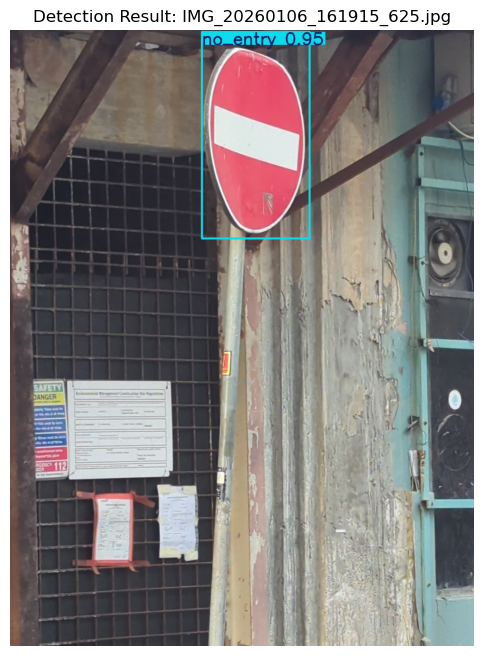

In [27]:
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
from pathlib import Path

# Load model
model = YOLO("runs/detect/Outputs/sign_detector_v12/weights/best.pt")

# Pick an image to test
img_path = "YOLO_COCO/images/val/IMG_20260106_161915_625.jpg" # Change for any image to see manually

# 3. Run prediction
# save=True will save the result to runs/detect/predict/
results = model.predict(source=img_path, conf=0.25, save=False)

# Plot the result
for r in results:
    annotated_img = r.plot() 
    
    # Convert BGR to RGB for matplotlib
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Detection Result: {Path(img_path).name}")
    plt.show()

In [20]:
from ultralytics import YOLO
import pandas as pd
from pathlib import Path

model_path = "runs/detect/Outputs/sign_detector_v12/weights/best.pt"
model = YOLO(model_path)

# Run Validation
metrics = model.val(data="YOLO_COCO/data.yaml")

# Extract Global Metrics
print("--- Global Performance Metrics ---")
stats = {
    "Metric": ["Precision", "Recall", "mAP50", "mAP50-95"],
    "Value": [
        metrics.results_dict['metrics/precision(B)'],
        metrics.results_dict['metrics/recall(B)'],
        metrics.results_dict['metrics/mAP50(B)'],
        metrics.results_dict['metrics/mAP50-95(B)']
    ]
}
df_global = pd.DataFrame(stats)
print(df_global)

# Extract Per-Class Metrics
# Essential for Task 2 to show which signs the model handles best
class_report = []
for i, name in model.names.items():
    class_report.append({
        "Traffic Sign": name,
        "Precision": metrics.box.p[i],
        "Recall": metrics.box.r[i],
        "mAP50": metrics.box.ap50[i]
    })

df_class = pd.DataFrame(class_report)
print("\n--- Per-Class Performance ---")
print(df_class)

# Locate Visual Files for your Report
val_plot_dir = Path(metrics.save_dir)
print(f"\nCopy these images from {val_plot_dir} for report:")
print(f"1. Confusion Matrix: {val_plot_dir / 'confusion_matrix.png'}")
print(f"2. Precision-Recall Curve: {val_plot_dir / 'PR_curve.png'}")
print(f"3. F1-Confidence Curve: {val_plot_dir / 'F1_curve.png'}")

Ultralytics 8.4.9 🚀 Python-3.13.11 torch-2.9.1 CPU (Apple M4)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1324.8±777.9 MB/s, size: 1451.6 KB)
val: Scanning /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/labels/val.cache... 89 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 89/89 20.7Mit/s 0.0s
val: /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/20260110_172633.jpg: corrupt JPEG restored and saved
val: /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/20260110_172734.jpg: corrupt JPEG restored and saved
val: /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_20251123_145355.jpg: corrupt JPEG restored and saved
val: /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_20251123_145510.jpg: corrupt JPEG restored and saved
val: /Users/nfilipovpajic/UM/adv_CV/YOLO_COCO/images/val/IMG_20251123_145525.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P    

In [21]:
import os
import shutil
from pathlib import Path

# Paths based on your previous code
results_dir = Path("runs/detect/Outputs/sign_detector_v12")
save_to = Path("Final_Deliverables/Detector_1_Sign_Type")
save_to.mkdir(parents=True, exist_ok=True)

# 1. Mandatory Files for the 20-page Report
# These files are generated automatically by YOLOv8 during training/validation
essential_visuals = [
    "confusion_matrix.png",   # Critical Requirement: Shows class confusion
    "results.png",            # Shows training/validation loss and mAP curves
    "PR_curve.png",           # Precision-Recall curve for your report
    "F1_curve.png",           # F1-Confidence curve
    "val_batch0_labels.jpg",  # Ground truth labels for visual comparison
    "val_batch0_pred.jpg"     # Model predictions for visual comparison
]

# 2. Mandatory Model Weight
essential_weights = ["weights/best.pt"]

print(f"--- Collecting files from: {results_dir} ---")

for file_name in essential_visuals + essential_weights:
    src = results_dir / file_name
    if src.exists():
        dest = save_to / os.path.basename(file_name)
        shutil.copy(src, dest)
        print(f"[SAVED] {file_name}")
    else:
        print(f"[MISSING] {file_name} - Did you finish the training/validation?")

# 3. Analytics CSV (from Task 3)
csv_path = Path("Outputs/detection_results.csv")
if csv_path.exists():
    shutil.copy(csv_path, save_to / "detection_analytics.csv")
    print(f"[SAVED] detection_results.csv")

print(f"\nAll essential files are now in: {save_to.absolute()}")

--- Collecting files from: runs/detect/Outputs/sign_detector_v12 ---
[SAVED] confusion_matrix.png
[SAVED] results.png
[MISSING] PR_curve.png - Did you finish the training/validation?
[MISSING] F1_curve.png - Did you finish the training/validation?
[SAVED] val_batch0_labels.jpg
[SAVED] val_batch0_pred.jpg
[SAVED] weights/best.pt

All essential files are now in: /Users/nfilipovpajic/UM/adv_CV/Final_Deliverables/Detector_1_Sign_Type
